In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


In [32]:
X,y=make_blobs(n_samples=1000,centers=3,random_state=0,n_features=2)
##centers are no of clusters
##these clusters won't be used in kmeans algorithm

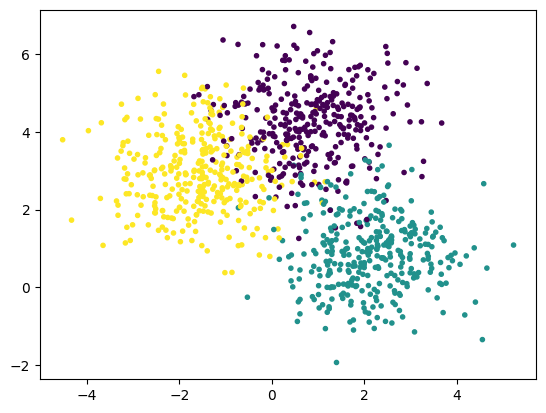

In [33]:
plt.scatter(X[:,0],X[:,1],c=y,marker='.')

In [34]:
##standardization -->feature scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [36]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [37]:
from sklearn.cluster import KMeans

In [38]:
###Elbow method to find optimal number of clusters
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++',random_state=42)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [39]:
wcss

[1599.9999999999995,
 797.7572762170764,
 451.2013828554713,
 382.552330931965,
 319.6051617450416,
 264.91574934375694,
 236.0800419181537,
 213.7517729641702,
 195.93782925410432,
 170.1441569749138]

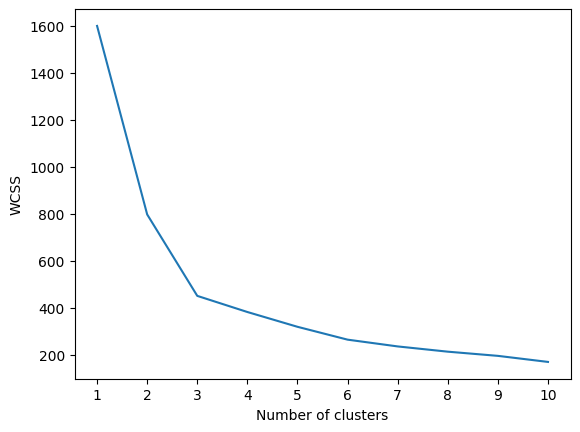

In [40]:
###plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [41]:
kmeans=KMeans(n_clusters=3,init='k-means++')

In [42]:
kmeans.fit_predict(X_train_scaled)

array([2, 1, 1, 0, 2, 0, 1, 0, 2, 2, 1, 1, 1, 1, 2, 0, 2, 2, 1, 2, 1, 0,
       2, 2, 1, 0, 1, 1, 2, 0, 2, 0, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 2, 0,
       2, 2, 1, 1, 1, 0, 1, 0, 1, 1, 2, 1, 0, 2, 1, 2, 2, 0, 2, 0, 1, 0,
       0, 1, 0, 0, 2, 1, 1, 2, 1, 1, 0, 2, 1, 0, 0, 1, 0, 1, 1, 1, 2, 0,
       1, 1, 1, 0, 0, 1, 2, 1, 2, 2, 1, 0, 1, 1, 0, 2, 0, 2, 1, 1, 2, 2,
       2, 2, 0, 0, 2, 1, 1, 0, 0, 1, 0, 0, 2, 0, 1, 2, 2, 2, 1, 1, 2, 1,
       2, 0, 0, 0, 2, 0, 2, 2, 1, 2, 0, 2, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 2, 1, 2, 0, 1, 2, 1, 0, 2, 2, 2, 1, 0, 1, 2, 1, 1, 0, 0, 0,
       0, 0, 2, 2, 0, 1, 1, 1, 0, 1, 1, 1, 2, 1, 1, 2, 2, 2, 2, 2, 0, 1,
       2, 2, 1, 1, 1, 1, 0, 2, 2, 1, 1, 1, 2, 0, 2, 1, 1, 1, 0, 2, 1, 1,
       1, 2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 2, 2, 2, 0, 0, 1, 1, 2, 2, 0, 0,
       2, 0, 0, 0, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 0, 1, 2, 0, 1,
       0, 1, 0, 0, 2, 0, 0, 2, 0, 2, 1, 0, 2, 0, 0, 1, 0, 2, 0, 2, 0, 2,
       0, 2, 1, 2, 2, 0, 2, 1, 0, 1, 1, 1, 0, 0, 0,

In [43]:
y_pred=kmeans.predict(X_test_scaled)

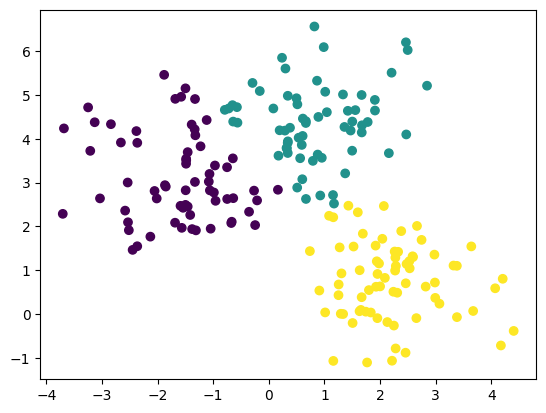

In [44]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [45]:
###Validating the k value
##knee locater
##Silhoutee score

In [46]:
!pip install kneed

In [47]:
from kneed import KneeLocator

In [49]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [ ]:
kl.elbow ##validating

np.int64(3)

In [51]:
## Silhoutte scoring 
from sklearn.metrics import silhouette_score

In [52]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [53]:
silhouette_coefficients

[0.46126062306955484,
 0.47137726523156126,
 0.3823541311797921,
 0.33087172530969305,
 0.35748492708856633,
 0.32442593163730266,
 0.32324952768315546,
 0.3346201043631073,
 0.3391809879572301]

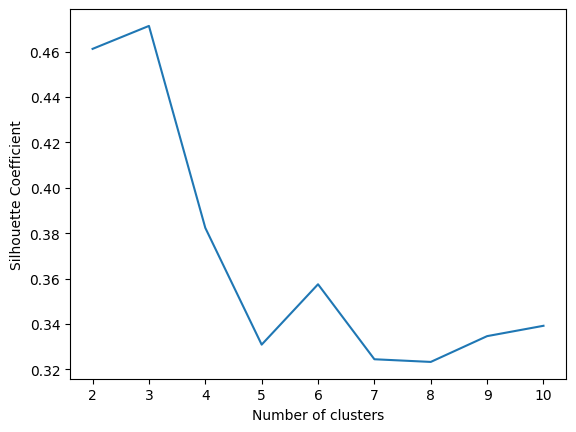

In [54]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()

In [ ]:
##since highest value is at 3 so we can choose k=3 